# AdventureWorks Reseller Segmentation
## Two-Stage K-Means Clustering - Commercial Account Analysis

**Dataset:** Microsoft AdventureWorks Sample Data  
**Tools:** Python, scikit-learn, pandas, matplotlib  
**Date:** 2026


## Executive Summary

**The single most important finding in this analysis:**

> **53% of AdventureWorks resellers (335 of 635) are unprofitable - collectively generating $48.4M in revenue at negative margins.**

This is not a data quality issue. It is a structural commercial problem visible consistently across the full four year transaction history.

**Five segment output:**

| Segment | Count | Total Revenue | Avg Margin | Priority |
|---|---|---|---|---|
| Star Resellers | 64 | 23.6M | +9% | Protect and invest |
| High Margin Specialists | 235 | 8.4M | +9% | Grow - highest opportunity |
| High Volume At Risk | 78 | 32.9M | -4% | Urgent commercial review |
| Mid Tier At Risk | 220 | 12.8M | -7% | Systematic rationalisation |
| Low Volume At Risk | 38 | 2.7M | -5% | Exit - cost exceeds return |

**Key observation:** Star Resellers and High Margin Specialists share identical average margins (+9%). The only difference is revenue scale, meaning the path from Specialist to Star is a volume growth problem, not a profitability problem. This is the most actionable finding for a sales team.

> *For business recommendations scroll to Section 11. For technical methodology start at Section 3.*


## Recommendations

---

### 1. Urgent - Reprice or exit High Volume At Risk accounts
78 resellers generating $32.9M revenue at -4% margin represent the single largest commercial risk in the reseller network. The more revenue these accounts generate the more money the business loses. A pricing review targeting these 78 accounts specifically rather than blanket reseller pricing changes would have an immediate and material impact on total profitability.

**Suggested action:** Export the High Volume At Risk list from Power BI and prioritise for account manager review within 30 days. For each account determine whether the margin issue is driven by product mix, discounting, or cost structure - each requires a different response.

---

### 2. Invest in High Margin Specialists to convert them to Stars
235 resellers achieving +9% margin at lower revenue volumes represent the clearest growth opportunity in the network. They have already demonstrated they can operate profitably the question is whether their revenue can be grown.

**Suggested action:** Analyse what Star Resellers do differently in terms of product mix, order frequency, and territory. Apply those characteristics as a targeting model to identify which High Margin Specialists have the highest conversion potential. Focus sales development resources on this group rather than the At Risk accounts.

---

### 3. Systematically rationalise Mid Tier At Risk accounts
220 resellers at -7% margin generating $12.8M in revenue. This is the largest unprofitable segment by count and the most complex to address - too large to individually review and too significant to ignore.

**Suggested action:** Develop a scoring model combining margin, revenue trend, and recency to prioritise which Mid Tier accounts to attempt to fix vs exit. Accounts with declining order frequency and consistently negative margins are exit candidates. Accounts with improving recency may respond to pricing intervention.

---

### 4. Exit Low Volume At Risk accounts
38 resellers at -5% margin generating $2.7M revenue. The cost of maintaining these relationships account management time, order processing, logistics almost certainly exceeds the revenue return at negative margin.

**Suggested action:** These are the easiest commercial decision. Notify and transition these accounts. The freed capacity can be redirected to developing High Margin Specialists.

---

### 5. Protect Star Resellers from disruption
64 resellers generating $23.6M at +9% margin are the proof that the reseller model works when managed correctly. Any pricing changes or policy updates arising from the At Risk account review must explicitly protect Star Reseller relationships.

**Suggested action:** Assign dedicated account managers to Star Resellers. Ensure any network-wide policy changes are assessed for impact on this segment before implementation.

---

### 6. Track segment migration over time
Static segmentation computed once has limited long-term value. As new transaction data arrives resellers will move between segments, an At Risk account that improves its margin profile should graduate to Specialist or Star.

**Suggested action:** Re-run this segmentation quarterly and track segment migration. An account moving from High Volume At Risk to Star Reseller is a success story worth measuring.

---


## 1. Introduction and Business Problem

The AdventureWorks reseller network spans 635 active resellers across 6 countries - United States, Canada, United Kingdom, France, Germany, and Australia. They operate across three business types: Value Added Resellers, Warehouse resellers, and Specialty Bike Shops.

The dashboard analysis identified that the reseller channel operates at approximately 0.6% blended profit margin compared to 41% for the Internet channel. This notebook investigates the reseller network in more depth to answer:

> *Which resellers are driving that thin margin - and can we identify which accounts to fix, grow, or exit?*

### What stood out before modelling

Three things shaped the analytical approach:

1. **The margin distribution is bimodal** - initial exploration revealed resellers are not uniformly thin-margin. Some are genuinely profitable (+37.7% max) while others are deeply unprofitable (-60% min). The blended 0.6% average was masking this bifurcation.

2. **Revenue concentration** - a small number of resellers generate a disproportionate share of total revenue. Standard K-Means is sensitive to these outliers and tends to create one cluster containing the high-revenue accounts regardless of their profitability.

3. **The business question is profitability-first** - a sales team does not need mathematically optimal clusters. They need to know which accounts to protect, grow, fix, and exit. That framing drove the two-stage clustering design.

### Why two-stage clustering

Initial single-stage K-Means returned K=2 as optimal which were two segments differentiated almost entirely by revenue scale with profitable and unprofitable resellers mixed into each group. A sales manager cannot act on that.

The two-stage approach was done by splitting by profitability first, then clustering within each group. It was designed specifically to surface the profitability story that single-stage clustering was obscuring.


## 2. Setup and Configuration

In [1]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

# ── Configuration ─────────────────────────────────────────────
FILE_PATH = "AdventureWorks_Sales_Cleaned.xlsx"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
MAX_K = 5

# Colour palette - matches Power BI dashboard theme
COLOUR_ACTUAL = "#1F4E79"
COLOUR_FORECAST = "#2563eb"
COLOUR_HIGHLIGHT = "#E63946"
SEGMENT_COLOURS = {
    "Star Resellers": "#1F4E79",
    "High Margin Specialists": "#2563eb",
    "High Volume At Risk": "#E63946",
    "Mid Tier At Risk": "#F97316",
    "Low Volume At Risk": "#FCA5A5",
}

print("Setup complete")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Setup complete
Output directory: C:\Users\he145100\outputs


## 3. Data Loading

Five sheets are required for this analysis - Sales, Reseller metadata, Sales Order channel, Product categories, and Sales Territory for geographic enrichment.


In [2]:
def load_data(file_path: str) -> dict[str, pd.DataFrame]:
    """
    Loads all sheets required for reseller segmentation.

    Parameters
    ----------
    file_path : str
        Path to cleaned AdventureWorks workbook

    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary of dataframes keyed by short name
    """
    sheets = {
        "sales": "Sales",
        "reseller": "Reseller",
        "sales_order": "Sales Order",
        "product": "Product",
        "territory": "Sales Territory",
    }
    data = {}
    for key, sheet_name in sheets.items():
        data[key] = pd.read_excel(file_path, sheet_name=sheet_name)
        print(f"  Loaded {sheet_name:<25} {len(data[key]):>7,} rows")
    return data

print("Loading data...")
data = load_data(FILE_PATH)
print("\nAll sheets loaded")


Loading data...
  Loaded Sales                     121,253 rows
  Loaded Reseller                      701 rows
  Loaded Sales Order               121,253 rows
  Loaded Product                       397 rows
  Loaded Sales Territory                11 rows

All sheets loaded


## 4. Feature Engineering

The goal is to describe each reseller's commercial behaviour across four dimensions:

- **Scale** - how much revenue do they generate
- **Activity** - how frequently do they order
- **Profitability** - what margin do they return
- **Breadth** - how wide is their product category mix

Six features were engineered to capture these dimensions. Recency was added as a fifth dimension to identify accounts that have gone quiet which is a potential churn signal worth separating from consistently active resellers.


In [3]:
# Filter to reseller channel transactions
sales = data["sales"].copy()
sales_order = data["sales_order"].copy()
product = data["product"].copy()

sales = sales[sales["ResellerKey"] != -1].copy()
sales = sales.merge(
    sales_order[["SalesOrderLineKey", "Channel"]],
    on="SalesOrderLineKey", how="left"
)
sales = sales[sales["Channel"] == "Reseller"].copy()
sales = sales.merge(
    product[["ProductKey", "Category", "Subcategory"]],
    on="ProductKey", how="left"
)
sales = sales.merge(
    data["territory"][["SalesTerritoryKey", "Region", "Country", "Group"]],
    on="SalesTerritoryKey", how="left"
)

sales["Profit"] = sales["Sales Amount"] - sales["Total Product Cost"]
sales["OrderDate"] = pd.to_datetime(
    sales["OrderDateKey"].astype(str), format="%Y%m%d"
)

reference_date = sales["OrderDate"].max()

# Aggregate to reseller level
features = sales.groupby("ResellerKey").agg(
    Total_Revenue=("Sales Amount", "sum"),
    Total_Orders=("SalesOrderLineKey", "count"),
    Total_Cost=("Total Product Cost", "sum"),
    Total_Profit=("Profit", "sum"),
    Unique_Categories=("Category", "nunique"),
    Unique_Products=("ProductKey", "nunique"),
    Last_Order_Date=("OrderDate", "max"),
    First_Order_Date=("OrderDate", "min"),
).reset_index()

# Derived features
features["Profit_Margin_Pct"] = (
    features["Total_Profit"] / features["Total_Revenue"]
).round(4)
features["Avg_Order_Value"] = (
    features["Total_Revenue"] / features["Total_Orders"]
).round(2)
features["Recency_Days"] = (
    reference_date - features["Last_Order_Date"]
).dt.days
features["Tenure_Days"] = (
    features["Last_Order_Date"] - features["First_Order_Date"]
).dt.days

# Merge reseller metadata
reseller_meta = data["reseller"][
    ["ResellerKey", "Reseller", "Business Type", "City", "Country-Region"]
]
features = features.merge(reseller_meta, on="ResellerKey", how="left")

print(f"Feature table built - {len(features):,} resellers")
print(f"\nFeature summary:")
print(features[[
    "Total_Revenue", "Total_Orders", "Profit_Margin_Pct",
    "Avg_Order_Value", "Unique_Categories", "Recency_Days"
]].describe().round(2))


Feature table built - 635 resellers

Feature summary:
       Total_Revenue  Total_Orders  Profit_Margin_Pct  Avg_Order_Value  \
count         635.00        635.00             635.00           635.00   
mean       126693.85         95.83               0.01          1094.11   
std        173515.35        112.41               0.10           816.40   
min             1.37          1.00              -0.60             1.37   
25%          7386.93         12.00              -0.04           575.24   
50%         45502.97         52.00              -0.00           941.38   
75%        176784.40        139.00               0.09          1373.65   
max        877107.19        530.00               0.38          7277.01   

       Unique_Categories  Recency_Days  
count             635.00        635.00  
mean                3.13        159.46  
std                 1.01        239.64  
min                 1.00          0.00  
25%                 2.00         13.00  
50%                 4.00         

## 5. Margin Distribution - The Critical Finding

Before any clustering the margin distribution tells the most important story in this dataset. This is the finding that changed the entire analytical approach.


Margin distribution:
  Negative margin (unprofitable):  335 resellers (52.8%)
  Zero margin (breakeven):           1 resellers (0.2%)
  Positive margin (profitable):    299 resellers (47.1%)

Margin statistics:
count    635.0000
mean       0.0101
std        0.0996
min       -0.5997
25%       -0.0420
50%       -0.0025
75%        0.0882
max        0.3767
Name: Profit_Margin_Pct, dtype: float64


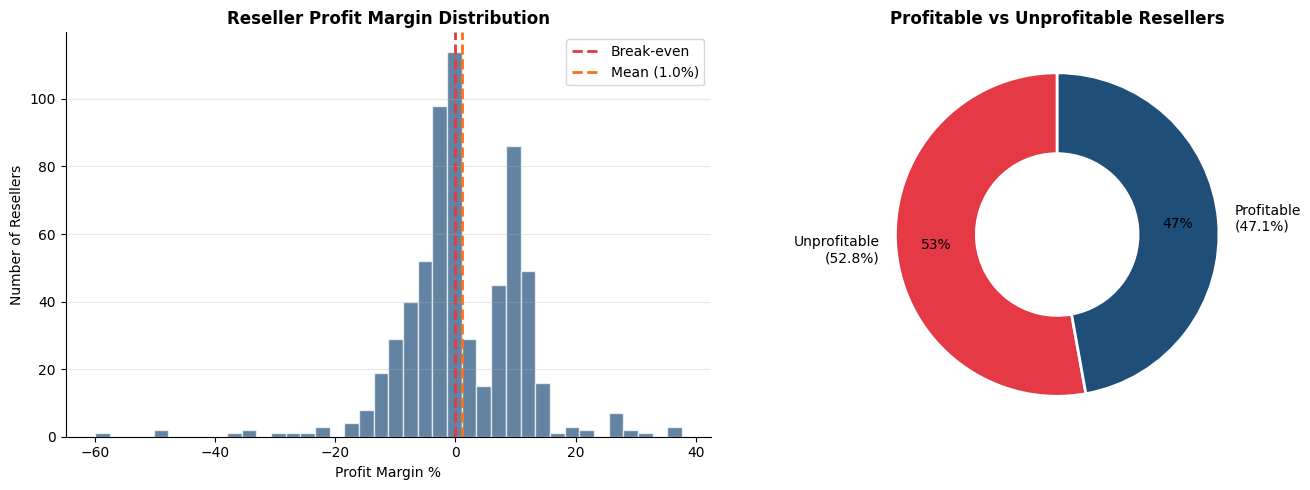

Margin distribution chart saved


In [4]:
# Margin distribution analysis
neg = (features["Profit_Margin_Pct"] < 0).sum()
zero = (features["Profit_Margin_Pct"] == 0).sum()
pos = (features["Profit_Margin_Pct"] > 0).sum()
total = len(features)

print("Margin distribution:")
print(f"  Negative margin (unprofitable): {neg:>4} resellers ({neg/total:.1%})")
print(f"  Zero margin (breakeven):        {zero:>4} resellers ({zero/total:.1%})")
print(f"  Positive margin (profitable):   {pos:>4} resellers ({pos/total:.1%})")
print(f"\nMargin statistics:")
print(features["Profit_Margin_Pct"].describe().round(4))

# Visualise the margin distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    features["Profit_Margin_Pct"] * 100,
    bins=40, color=COLOUR_ACTUAL, alpha=0.7, edgecolor="white"
)
axes[0].axvline(x=0, color=COLOUR_HIGHLIGHT, linewidth=2,
                linestyle="--", label="Break-even")
axes[0].axvline(
    x=features["Profit_Margin_Pct"].mean() * 100,
    color="#F97316", linewidth=2, linestyle="--",
    label=f"Mean ({features['Profit_Margin_Pct'].mean():.1%})"
)
axes[0].set_title("Reseller Profit Margin Distribution", fontweight="bold")
axes[0].set_xlabel("Profit Margin %")
axes[0].set_ylabel("Number of Resellers")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Profitable vs unprofitable donut
sizes = [neg, pos]
labels = [f"Unprofitable\n({neg/total:.1%})", f"Profitable\n({pos/total:.1%})"]
colours = [COLOUR_HIGHLIGHT, COLOUR_ACTUAL]
axes[1].pie(sizes, labels=labels, colors=colours, autopct="%1.0f%%",
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
axes[1].set_title("Profitable vs Unprofitable Resellers", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reseller_margin_distribution.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Margin distribution chart saved")


### What this margin distribution means

**53% of resellers are unprofitable.** This is not a rounding issue or a data artefact, it is consistent across the full four year transaction history.

The mean margin of 1% is being dragged upward by the profitable minority. The median margin is -0.25% meaning the typical reseller relationship is slightly loss-making.

This finding fundamentally changed the clustering approach. Running K-Means on all 635 resellers together would average out this profitability bifurcation and produce segments where every cluster contains a mix of profitable and unprofitable accounts. A sales team cannot act on that.

The solution: split by profitability first, then cluster within each group.


## 6. Initial Approach - Why Single-Stage K-Means Failed

Before settling on the two-stage approach a standard single-stage K-Means was run to confirm the problem.


In [5]:
# Single stage K-Means for comparison
clustering_features_single = [
    "Total_Revenue", "Total_Orders", "Profit_Margin_Pct",
    "Avg_Order_Value", "Unique_Categories", "Recency_Days",
]

X_single = features[clustering_features_single].fillna(0).values
scaler_single = StandardScaler()
X_single_scaled = scaler_single.fit_transform(X_single)

# Evaluate K values
inertia_vals = []
silhouette_vals = []

for k in range(2, MAX_K + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_single_scaled)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_single_scaled, labels))

optimal_k_single = silhouette_vals.index(max(silhouette_vals)) + 2
print(f"Single-stage optimal K: {optimal_k_single}")
print(f"Silhouette scores: {[round(s, 3) for s in silhouette_vals]}")

# Fit and show what K=2 produced
km_single = KMeans(n_clusters=optimal_k_single, random_state=RANDOM_STATE, n_init=10)
features["Cluster_Single"] = km_single.fit_predict(X_single_scaled)

print("\nSingle-stage K=2 result:")
print(features.groupby("Cluster_Single").agg(
    Count=("ResellerKey", "count"),
    Avg_Revenue=("Total_Revenue", "mean"),
    Avg_Margin=("Profit_Margin_Pct", "mean"),
    Profitable_Count=("Profit_Margin_Pct", lambda x: (x > 0).sum()),
    Unprofitable_Count=("Profit_Margin_Pct", lambda x: (x < 0).sum()),
).round(3))

features.drop(columns=["Cluster_Single"], inplace=True)


Single-stage optimal K: 2
Silhouette scores: [0.327, 0.319, 0.287, 0.298]

Single-stage K=2 result:
                Count  Avg_Revenue  Avg_Margin  Profitable_Count  \
Cluster_Single                                                     
0                 481    44663.744       0.010               235   
1                 154   382904.780       0.012                64   

                Unprofitable_Count  
Cluster_Single                      
0                              245  
1                               90  


### Why K=2 was not good enough

The single-stage result shows both clusters contain a mix of profitable and unprofitable resellers. The algorithm separated by revenue scale (high volume vs low volume) but ignored the profitability bifurcation entirely.

This is the classic K-Means failure mode on business data with outliers:
- **Outlier sensitivity** - the high-revenue resellers pull their own cluster regardless of margin
- **Spherical assumption** - K-Means creates roughly circular clusters which doesn't suit data with a strong revenue skew
- **Scale masking** - without explicit profitability weighting revenue dominates and margin differences get averaged away

A sales team presented with these two segments would not know which accounts to fix and which to grow. The segmentation is mathematically valid but commercially useless.


## 7. Two-Stage Clustering

The redesigned approach explicitly separates profitable from unprofitable resellers before clustering. This ensures margin is a segmentation dimension rather than an averaged-out noise term.

**Stage 1** - Split by profitability (profitable vs unprofitable)  
**Stage 2** - Cluster within each group independently using revenue, activity, and recency features


In [6]:
# ── Stage 1 - Split by profitability ─────────────────────────
unprofitable = features[features["Profit_Margin_Pct"] < 0].copy()
breakeven = features[features["Profit_Margin_Pct"] == 0].copy()
profitable = features[features["Profit_Margin_Pct"] > 0].copy()

# Merge breakeven into unprofitable - single account not worth own segment
unprofitable = pd.concat([unprofitable, breakeven])

print(f"Unprofitable (incl. breakeven): {len(unprofitable)} ({len(unprofitable)/len(features):.1%})")
print(f"Profitable:                     {len(profitable)} ({len(profitable)/len(features):.1%})")

# ── Stage 2a - Cluster unprofitable resellers ─────────────────
# Margin excluded from features - all are negative so it adds no signal
# Focus on scale, activity, and recency to find actionable sub-groups
clustering_features_unprof = [
    "Total_Revenue", "Total_Orders",
    "Avg_Order_Value", "Unique_Categories", "Recency_Days",
]

X_unprof = unprofitable[clustering_features_unprof].fillna(0).values
scaler_unprof = StandardScaler()
X_unprof_scaled = scaler_unprof.fit_transform(X_unprof)

sil_unprof = []
for k in range(2, MAX_K + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_unprof_scaled)
    sil_unprof.append(silhouette_score(X_unprof_scaled, labels))

optimal_k_unprof = sil_unprof.index(max(sil_unprof)) + 2
print(f"\nUnprofitable group - optimal K: {optimal_k_unprof}")
print(f"Silhouette scores: {[round(s, 3) for s in sil_unprof]}")

km_unprof = KMeans(n_clusters=optimal_k_unprof, random_state=RANDOM_STATE, n_init=10)
unprofitable["Cluster_Unprof"] = km_unprof.fit_predict(X_unprof_scaled)

# Label unprofitable sub-segments by revenue
unprof_summary = unprofitable.groupby("Cluster_Unprof")["Total_Revenue"].mean()
revenue_rank_unprof = unprof_summary.rank(ascending=False)

unprof_label_map = {}
for cluster in unprof_summary.index:
    rank = revenue_rank_unprof[cluster]
    if rank == 1:
        unprof_label_map[cluster] = "High Volume At Risk"
    elif rank == 2:
        unprof_label_map[cluster] = "Mid Tier At Risk"
    else:
        unprof_label_map[cluster] = "Low Volume At Risk"

unprofitable["Segment"] = unprofitable["Cluster_Unprof"].map(unprof_label_map)

# ── Stage 2b - Cluster profitable resellers ───────────────────
# Margin included here - profitable resellers differ meaningfully
# in how they achieve profitability (high margin niche vs high volume)
clustering_features_prof = [
    "Total_Revenue", "Total_Orders", "Profit_Margin_Pct",
    "Avg_Order_Value", "Unique_Categories", "Recency_Days",
]

X_prof = profitable[clustering_features_prof].fillna(0).values
scaler_prof = StandardScaler()
X_prof_scaled = scaler_prof.fit_transform(X_prof)

sil_prof = []
for k in range(2, MAX_K + 1):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_prof_scaled)
    sil_prof.append(silhouette_score(X_prof_scaled, labels))

optimal_k_prof = sil_prof.index(max(sil_prof)) + 2
print(f"\nProfitable group - optimal K: {optimal_k_prof}")
print(f"Silhouette scores: {[round(s, 3) for s in sil_prof]}")

km_prof = KMeans(n_clusters=optimal_k_prof, random_state=RANDOM_STATE, n_init=10)
profitable["Cluster_Prof"] = km_prof.fit_predict(X_prof_scaled)

# Label profitable segments by revenue and margin
prof_summary = profitable.groupby("Cluster_Prof").agg(
    Avg_Revenue=("Total_Revenue", "mean"),
    Avg_Margin=("Profit_Margin_Pct", "mean"),
).round(4)

revenue_rank_prof = prof_summary["Avg_Revenue"].rank(ascending=False)
margin_rank_prof = prof_summary["Avg_Margin"].rank(ascending=False)

prof_label_map = {}
for cluster in prof_summary.index:
    rev_rank = revenue_rank_prof[cluster]
    mar_rank = margin_rank_prof[cluster]
    if rev_rank == 1 and mar_rank <= 2:
        prof_label_map[cluster] = "Star Resellers"
    elif rev_rank == 1:
        prof_label_map[cluster] = "High Volume Stars"
    elif mar_rank == 1:
        prof_label_map[cluster] = "High Margin Specialists"
    else:
        prof_label_map[cluster] = "Growth Partners"

profitable["Segment"] = profitable["Cluster_Prof"].map(prof_label_map)

# ── Combine all segments ──────────────────────────────────────
features_final = pd.concat([profitable, unprofitable]).reset_index(drop=True)

print("\n" + "=" * 60)
print("FINAL SEGMENT SUMMARY")
print("=" * 60)
summary = features_final.groupby("Segment").agg(
    Count=("ResellerKey", "count"),
    Avg_Revenue=("Total_Revenue", "mean"),
    Total_Revenue=("Total_Revenue", "sum"),
    Avg_Orders=("Total_Orders", "mean"),
    Avg_Margin=("Profit_Margin_Pct", "mean"),
    Avg_Categories=("Unique_Categories", "mean"),
).round(2)
print(f"\n{summary.to_string()}")


Unprofitable (incl. breakeven): 336 (52.9%)
Profitable:                     299 (47.1%)

Unprofitable group - optimal K: 3
Silhouette scores: [0.377, 0.405, 0.376, 0.396]

Profitable group - optimal K: 2
Silhouette scores: [0.347, 0.33, 0.297, 0.325]

FINAL SEGMENT SUMMARY

                         Count  Avg_Revenue  Total_Revenue  Avg_Orders  Avg_Margin  Avg_Categories
Segment                                                                                           
High Margin Specialists    235     35872.84     8430117.78       35.21        0.09            2.77
High Volume At Risk         78    422049.84    32919887.52      276.29       -0.04            3.91
Low Volume At Risk         220     58309.32    12828049.45       57.26       -0.07            3.11
Mid Tier At Risk            38     70348.61     2673247.00       41.45       -0.05            2.58
Star Resellers              64    368738.99    23599295.23      263.38        0.09            3.88


### Why the silhouette scores differ between groups

The unprofitable group achieves higher silhouette scores (peak 0.405 at K=3) than the profitable group (peak 0.347 at K=2).

This makes commercial sense since unprofitable accounts tend to share clear characteristics that make them naturally separable: high cost base, aggressive discounting, or low-margin product mix. The algorithm can cleanly distinguish high-volume unprofitable accounts from the long tail of small loss-making relationships.

Profitable resellers are more heterogeneous as they achieve profitability through different combinations of volume, product mix, and pricing discipline. The lower silhouette scores reflect genuine commercial diversity within the profitable group rather than poor clustering.


## 8. Segment Visualisation

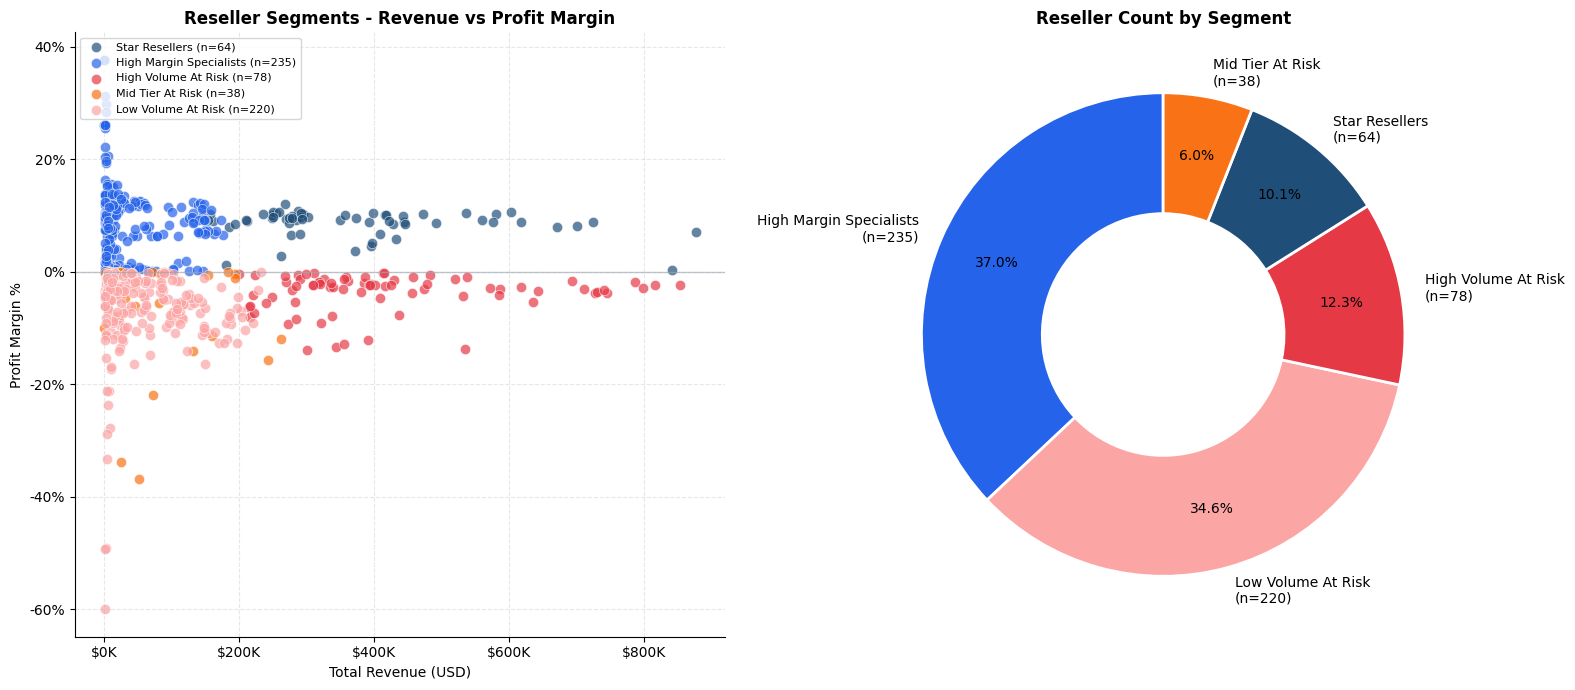

Segment visualisation saved


In [7]:
# Assign colours for consistent styling
features_final["Colour"] = features_final["Segment"].map(SEGMENT_COLOURS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter - Revenue vs Margin coloured by Segment
for segment, colour in SEGMENT_COLOURS.items():
    seg_data = features_final[features_final["Segment"] == segment]
    if len(seg_data) == 0:
        continue
    axes[0].scatter(
        seg_data["Total_Revenue"],
        seg_data["Profit_Margin_Pct"] * 100,
        c=colour,
        label=f"{segment} (n={len(seg_data)})",
        alpha=0.7, s=55,
        edgecolors="white", linewidths=0.5,
    )

axes[0].axhline(y=0, color="#9CA3AF", linewidth=1, linestyle="-", alpha=0.6)
axes[0].set_title("Reseller Segments - Revenue vs Profit Margin",
                  fontweight="bold")
axes[0].set_xlabel("Total Revenue (USD)")
axes[0].set_ylabel("Profit Margin %")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Donut - Count by Segment
segment_counts = features_final["Segment"].value_counts()
donut_colours = [SEGMENT_COLOURS.get(s, "#9CA3AF") for s in segment_counts.index]
axes[1].pie(
    segment_counts.values,
    labels=[f"{s}\n(n={v})" for s, v in segment_counts.items()],
    colors=donut_colours,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
)
axes[1].set_title("Reseller Count by Segment", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reseller_segments_final.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Segment visualisation saved")


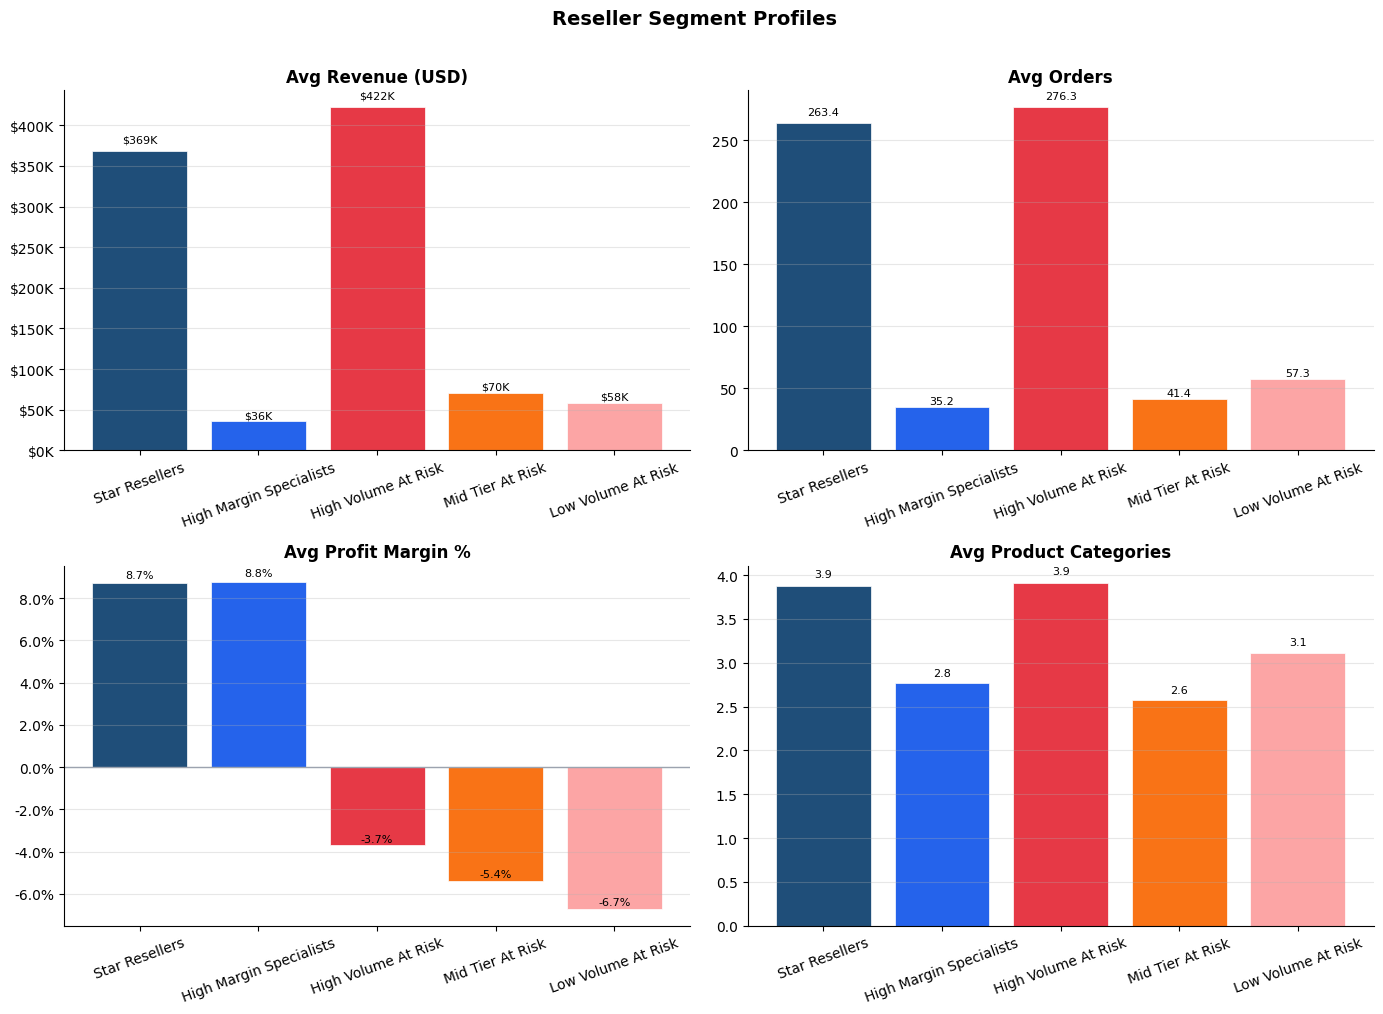

Segment profile chart saved


In [8]:
# Segment profiles - average feature values per segment
summary_plot = features_final.groupby("Segment").agg(
    Avg_Revenue=("Total_Revenue", "mean"),
    Avg_Orders=("Total_Orders", "mean"),
    Avg_Margin=("Profit_Margin_Pct", "mean"),
    Avg_Categories=("Unique_Categories", "mean"),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Reseller Segment Profiles", fontsize=14,
             fontweight="bold", y=1.01)

segment_order = [
    "Star Resellers", "High Margin Specialists",
    "High Volume At Risk", "Mid Tier At Risk", "Low Volume At Risk"
]
summary_plot = summary_plot.set_index("Segment").reindex(
    [s for s in segment_order if s in summary_plot["Segment"].values]
).reset_index()

bar_colours = [SEGMENT_COLOURS.get(s, "#9CA3AF")
               for s in summary_plot["Segment"]]

metrics = [
    ("Avg_Revenue", "Avg Revenue (USD)", axes[0, 0]),
    ("Avg_Orders", "Avg Orders", axes[0, 1]),
    ("Avg_Margin", "Avg Profit Margin %", axes[1, 0]),
    ("Avg_Categories", "Avg Product Categories", axes[1, 1]),
]

for metric, label, ax in metrics:
    bars = ax.bar(
        summary_plot["Segment"],
        summary_plot[metric],
        color=bar_colours,
        edgecolor="white", linewidth=0.5,
    )
    ax.set_title(label, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if metric == "Avg_Revenue":
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
    elif metric == "Avg_Margin":
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
        ax.axhline(y=0, color="#9CA3AF", linewidth=1)

    for bar in bars:
        height = bar.get_height()
        if metric == "Avg_Revenue":
            label_text = f"${height/1e3:.0f}K"
        elif metric == "Avg_Margin":
            label_text = f"{height*100:.1f}%"
        else:
            label_text = f"{height:.1f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + abs(height) * 0.02,
            label_text,
            ha="center", va="bottom", fontsize=8, fontweight="500",
        )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reseller_segment_profiles.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Segment profile chart saved")


## 9. PCA Cluster Visualisation

Principal Component Analysis reduces the six clustering features to two dimensions for visualisation. The clustering was performed in the full six-dimensional feature space - PCA is used here purely to check that the segments are meaningfully separated and not overlapping in unexpected ways.


PCA explained variance: PC1=41.9%, PC2=21.3%
Total explained: 63.3%


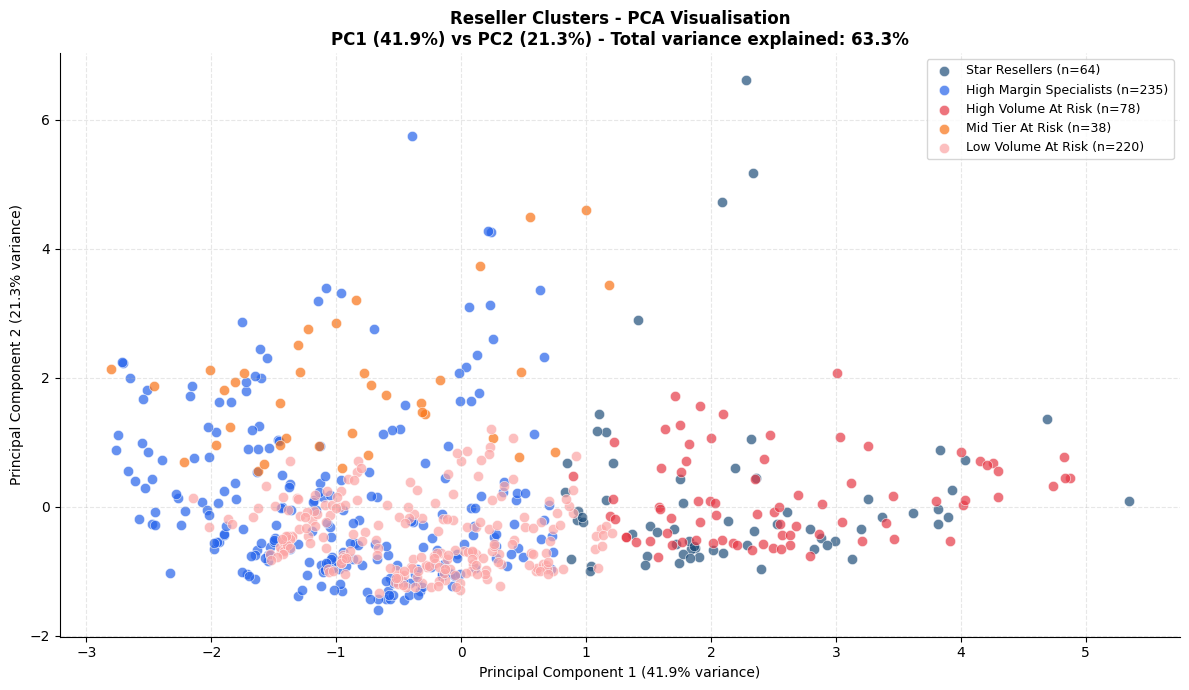

PCA visualisation saved


In [9]:
# Combine scaled features for PCA visualisation
all_features_cols = [
    "Total_Revenue", "Total_Orders", "Profit_Margin_Pct",
    "Avg_Order_Value", "Unique_Categories", "Recency_Days",
]

X_all = features_final[all_features_cols].fillna(0).values
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_all_scaled)
explained = pca.explained_variance_ratio_

print(f"PCA explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}")
print(f"Total explained: {sum(explained):.1%}")

fig, ax = plt.subplots(figsize=(12, 7))

for segment, colour in SEGMENT_COLOURS.items():
    mask = features_final["Segment"] == segment
    if mask.sum() == 0:
        continue
    ax.scatter(
        pca_coords[mask, 0],
        pca_coords[mask, 1],
        c=colour,
        label=f"{segment} (n={mask.sum()})",
        alpha=0.7, s=55,
        edgecolors="white", linewidths=0.5,
    )

ax.set_title(
    f"Reseller Clusters - PCA Visualisation\n"
    f"PC1 ({explained[0]:.1%}) vs PC2 ({explained[1]:.1%}) - "
    f"Total variance explained: {sum(explained):.1%}",
    fontweight="bold",
)
ax.set_xlabel(f"Principal Component 1 ({explained[0]:.1%} variance)")
ax.set_ylabel(f"Principal Component 2 ({explained[1]:.1%} variance)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reseller_pca_clusters.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("PCA visualisation saved")


## 10. Geographic and Business Type Analysis

Understanding where each segment concentrates geographically and by business type adds another layer of actionability. For example a sales territory manager needs to know which segments dominate their region.


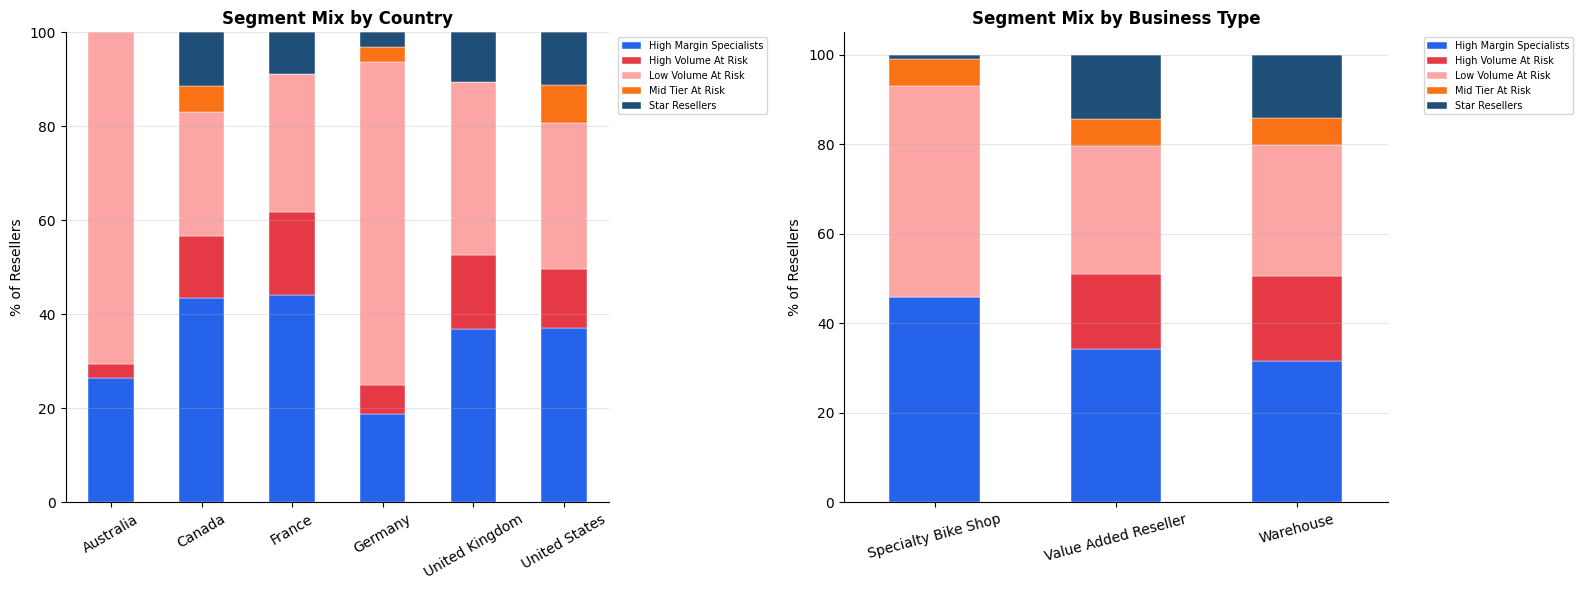

Geographic analysis chart saved

Reseller count by Country and Segment:
Segment         High Margin Specialists  High Volume At Risk  Low Volume At Risk  Mid Tier At Risk  Star Resellers
Country-Region                                                                                                    
Australia                             9                    1                  24                 0               0
Canada                               46                   14                  28                 6              12
France                               15                    6                  10                 0               3
Germany                               6                    2                  22                 1               1
United Kingdom                       14                    6                  14                 0               4
United States                       145                   49                 122                31              44

Reselle

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Segment by country
country_segment = features_final.groupby(
    ["Country-Region", "Segment"]
)["ResellerKey"].count().unstack(fill_value=0)

country_segment_pct = country_segment.div(
    country_segment.sum(axis=1), axis=0
) * 100

plot_colours = [SEGMENT_COLOURS.get(c, "#9CA3AF")
                for c in country_segment_pct.columns]

country_segment_pct.plot(
    kind="bar", stacked=True, ax=axes[0],
    color=plot_colours, edgecolor="white", linewidth=0.3,
)
axes[0].set_title("Segment Mix by Country", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("% of Resellers")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(loc="upper right", fontsize=7, bbox_to_anchor=(1.3, 1))
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Segment by business type
btype_segment = features_final.groupby(
    ["Business Type", "Segment"]
)["ResellerKey"].count().unstack(fill_value=0)

btype_segment_pct = btype_segment.div(
    btype_segment.sum(axis=1), axis=0
) * 100

btype_segment_pct.plot(
    kind="bar", stacked=True, ax=axes[1],
    color=plot_colours, edgecolor="white", linewidth=0.3,
)
axes[1].set_title("Segment Mix by Business Type", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("% of Resellers")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(loc="upper right", fontsize=7, bbox_to_anchor=(1.35, 1))
axes[1].grid(axis="y", alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reseller_geographic_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Geographic analysis chart saved")

# Summary tables
print("\nReseller count by Country and Segment:")
print(country_segment.to_string())
print("\nReseller count by Business Type and Segment:")
print(btype_segment.to_string())


## 11. Export for Power BI

The segmented reseller table is exported for Power BI integration. Load this CSV and create a relationship on ResellerKey with the Reseller_data table to enable segment filtering across all Reseller Analytics visuals.

**Power BI integration steps:**
1. Load `outputs/reseller_segments.csv`
2. Create relationship - ResellerKey to ResellerKey in Reseller_data table
3. Use Segment column to colour the scatter chart on Reseller Analytics page
4. Add a donut chart showing reseller count by Segment
5. Add Segment as a slicer to filter all page visuals


In [12]:
export_cols = [
    "ResellerKey", "Reseller", "Business Type", "City", "Country-Region",
    "Total_Revenue", "Total_Orders", "Total_Profit", "Profit_Margin_Pct",
    "Avg_Order_Value", "Unique_Categories", "Recency_Days",
    "Tenure_Days", "Segment",
]

output = features_final[export_cols].copy()
output_path = OUTPUT_DIR / "reseller_segments.csv"
output.to_csv(output_path, index=False)

print(f"Reseller segments exported to {output_path}")
print(f"   {len(output):,} resellers across {output['Segment'].nunique()} segments")

print("\nFinal segment summary:")
final_summary = output.groupby("Segment").agg(
    Count=("ResellerKey", "count"),
    Total_Revenue=("Total_Revenue", "sum"),
    Avg_Revenue=("Total_Revenue", "mean"),
    Avg_Margin=("Profit_Margin_Pct", "mean"),
).round(2).sort_values("Total_Revenue", ascending=False)
print(final_summary.to_string())


Reseller segments exported to outputs\reseller_segments.csv
   635 resellers across 5 segments

Final segment summary:
                         Count  Total_Revenue  Avg_Revenue  Avg_Margin
Segment                                                               
High Volume At Risk         78    32919887.52    422049.84       -0.04
Star Resellers              64    23599295.23    368738.99        0.09
Low Volume At Risk         220    12828049.45     58309.32       -0.07
High Margin Specialists    235     8430117.78     35872.84        0.09
Mid Tier At Risk            38     2673247.00     70348.61       -0.05


## 12. Limitations and Next Steps

### Limitations

**Static segmentation** - segments are computed on the full historical period (FY2018–FY2021). As new transaction data arrives resellers will shift behaviour. A production implementation would retrain quarterly and track segment migration - an At Risk account improving its margin profile should graduate to Specialist or Star over time.

**Margin calculation** - profit margin here is computed as (Sales Amount - Total Product Cost) / Sales Amount. This excludes operating costs, logistics, and account management overhead. True economic margin per reseller account is likely more negative than shown, particularly for High Volume At Risk accounts with complex logistics requirements.

**K-Means limitations** - even with two-stage clustering K-Means assumes spherical clusters and is sensitive to scale. Some resellers near segment boundaries may be misclassified. A follow-up analysis using hierarchical clustering or DBSCAN could validate the segment boundaries.

**Missing external context** - reseller contract terms, exclusive product arrangements, and strategic partnership agreements are not in the transaction data. Some apparently unprofitable accounts may have strategic value not captured in margin metrics alone.

### Next Steps

1. **Churn prediction** - build an XGBoost classifier to predict which resellers are likely to reduce orders or go inactive. High Volume At Risk accounts with declining recency are the highest priority for early intervention.

2. **Segment migration tracking** - re-run quarterly and build a Power BI visual showing how resellers move between segments over time.

3. **Customer segmentation** - apply RFM-based K-Means clustering to the 18,484 Internet customers. See `customer_segmentation.ipynb` for that analysis.

4. **Profitability deep dive** - investigate which product categories drive the negative margins in At Risk accounts. The product mix may be the root cause rather than pricing such as resellers buying low-margin Components vs high-margin Bikes would show exactly this pattern.
